In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import py_dss_interface

In [2]:
BASE_DIR = Path("..").resolve()
BASE_DIR


WindowsPath('C:/Users/grei-luis-felipe/Documents/fault-location/tcc-luis-felipe')

In [50]:
dss_file = BASE_DIR / "data" / "123Bus" / "Run_IEEE123Bus_GFLDaily_DynExp_py.dss"
dss_file = BASE_DIR / "data" / "123Bus" / "run_ieee_123_teste.dss"
dss_file

WindowsPath('C:/Users/grei-luis-felipe/Documents/fault-location/tcc-luis-felipe/data/123Bus/run_ieee_123_teste.dss')

In [53]:
dss = py_dss_interface.DSS()
dss.text("Clear")
dss.text(f"Compile ({dss_file})")
print("fim")


fim


In [7]:
dss.loadshapes.name = 'default'
dss.loadshapes.s_interval

3600.0

In [7]:
dss.monitors.name = "feederhead"
ia = dss.monitors.channel(7)
ib = dss.monitors.channel(9)
ic = dss.monitors.channel(11)



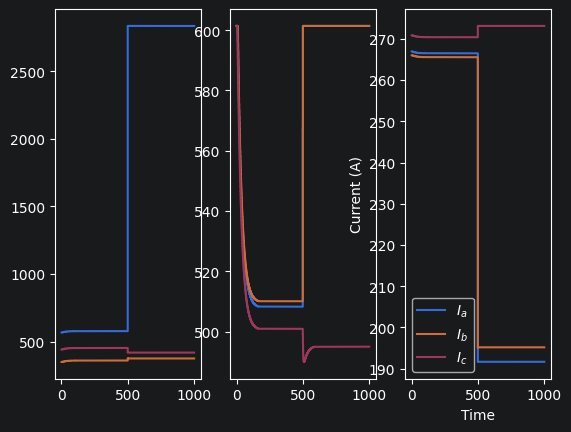

In [54]:
fig, ax = plt.subplots(1,3)

ax1, ax2, ax3 = ax.flatten()

dss.monitors.name = "feederhead"
ia = dss.monitors.channel(7)
ib = dss.monitors.channel(9)
ic = dss.monitors.channel(11)

ax1.plot(ia, drawstyle="steps-pre", label = "$I_a$")
ax1.plot(ib, drawstyle="steps-pre", label = "$I_b$")
ax1.plot(ic, drawstyle="steps-pre", label = "$I_c$")

dss.monitors.name = "pvvi"
ia = dss.monitors.channel(7)
ib = dss.monitors.channel(9)
ic = dss.monitors.channel(11)

ax2.plot(ia, drawstyle="steps-pre", label = "$I_a$")
ax2.plot(ib, drawstyle="steps-pre", label = "$I_b$")
ax2.plot(ic, drawstyle="steps-pre", label = "$I_c$")

dss.monitors.name = "pvvi"
ia = dss.monitors.channel(1)
ib = dss.monitors.channel(3)
ic = dss.monitors.channel(5)

ax3.plot(ia, drawstyle="steps-pre", label = "$I_a$")
ax3.plot(ib, drawstyle="steps-pre", label = "$I_b$")
ax3.plot(ic, drawstyle="steps-pre", label = "$I_c$")

plt.xlabel("Time")
plt.ylabel("Current (A)")
#plt.ylim(ymin=0, ymax=1000)
plt.legend()
plt.legend()
plt.show()

In [48]:
len(ic)

1000

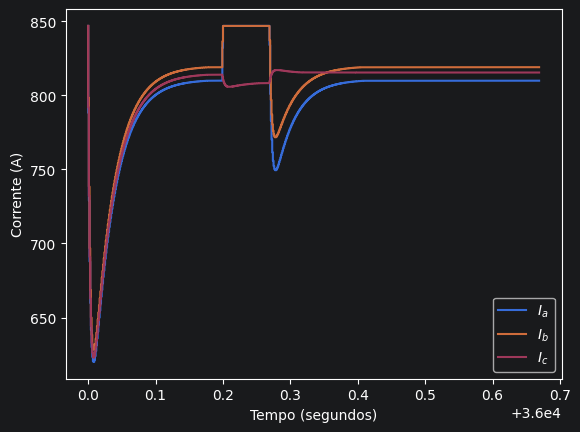

In [36]:
hora_inicio = 10
passo_tempo = 0.001
inicio_em_segundos = hora_inicio * 3600  # Converte 10:00 para 36000 segundos

# Cria a lista de tempo com o mesmo tamanho da lista 'ia'
# Para cada ponto 'i', o tempo é o (início + i * passo_tempo)
tempo = [inicio_em_segundos + (i * passo_tempo) for i in range(len(ia))]

fig, ax = plt.subplots()

# Adiciona a lista 'tempo' como primeiro argumento no plot
ax.plot(tempo, ia, drawstyle="steps-pre", label="$I_a$")
ax.plot(tempo, ib, drawstyle="steps-pre", label="$I_b$")
ax.plot(tempo, ic, drawstyle="steps-pre", label="$I_c$")

plt.xlabel("Tempo (segundos)")
plt.ylabel("Corrente (A)")
plt.legend()
plt.show()